In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

In [3]:
df = pd.read_csv('/content/test.csv', encoding = 'Latin-1')

In [4]:
df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [5]:
df.columns

Index(['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User',
       'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)'],
      dtype='object')

In [6]:
df.dtypes

,0
textID,object
text,object
sentiment,object
Time of Tweet,object
Age of User,object
Country,object
Population -2020,float64
Land Area (Km²),float64
Density (P/Km²),float64


In [7]:
df.drop(['textID', 'text', 'Time of Tweet'], axis = 1, inplace = True)

In [8]:
age_mapping = {
    '0-20': 10,
    '21-30': 25,
    '31-40': 35,
    '41-50': 45,
    '51-60': 55,
    '61-70': 65,
    '71-80': 75,
    '81-90': 85,
    '91-100': 95
}
df['Age of User'] = df['Age of User'].map(age_mapping)

In [9]:
le_country = LabelEncoder()
df['Country'] = le_country.fit_transform(df['Country'])

In [10]:
le_sentiment = LabelEncoder()
df['sentiment'] = le_sentiment.fit_transform(df['sentiment'])

In [11]:
X = df.drop('sentiment', axis = 1)
Y = df['sentiment']

In [12]:
X_train , X_test, Y_train,Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [13]:
pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
)

In [14]:
pipeline.fit(X_train, Y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('standardscaler', StandardScaler()),
                ('svc', SVC(random_state=42))])

In [15]:
y_pred = pipeline.predict(X_test)

In [16]:
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))
print("\nAccuracy Score:\n", accuracy_score(Y_test, y_pred))

Confusion Matrix:
 [[  2 208  11   5]
 [  2 227  34   5]
 [  3 188  16   4]
 [  0   0   0 258]]

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.01      0.02       226
           1       0.36      0.85      0.51       268
           2       0.26      0.08      0.12       211
           3       0.95      1.00      0.97       258

    accuracy                           0.52       963
   macro avg       0.47      0.48      0.40       963
weighted avg       0.48      0.52      0.43       963


Accuracy Score:
 0.5223260643821391


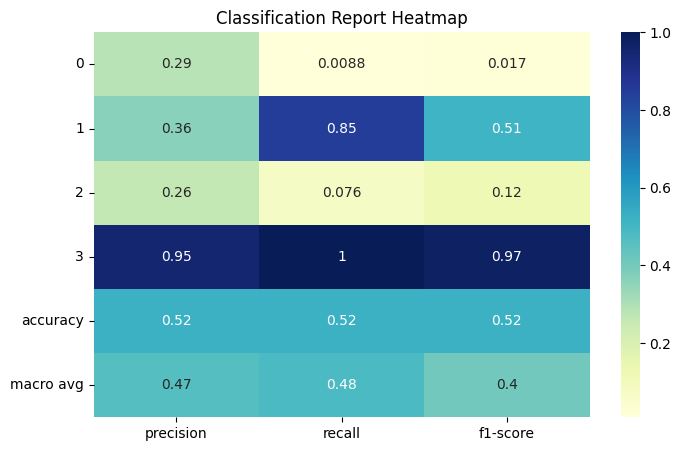

In [17]:
report = classification_report(Y_test, y_pred, output_dict=True)


df_report = pd.DataFrame(report).transpose()


plt.figure(figsize=(8, 5))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu")
plt.title("Classification Report Heatmap")
plt.show()


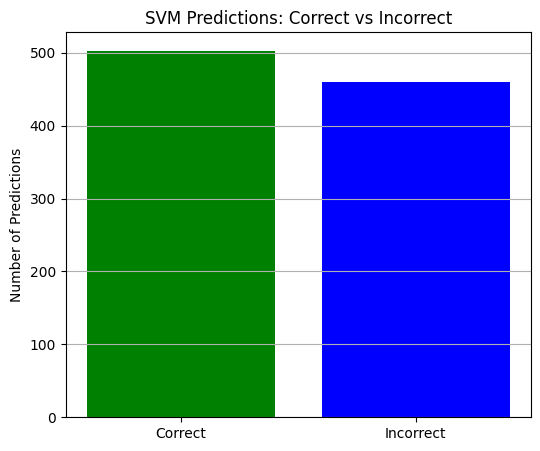

In [18]:

total = len(Y_test)
correct = (Y_test == y_pred).sum()
incorrect = total - correct

labels = ['Correct', 'Incorrect']
counts = [correct, incorrect]

plt.figure(figsize=(6, 5))
plt.bar(labels, counts, color=['green', 'blue'])
plt.title('SVM Predictions: Correct vs Incorrect')
plt.ylabel('Number of Predictions')
plt.grid(axis='y')
plt.show()